In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter

# Path to captions file
captions_path = "../data/captions.txt"
images_dir = "../data/Images"

df = pd.read_csv(captions_path)
print(df.shape)
df.head() 

Matplotlib is building the font cache; this may take a moment.


(40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [2]:
num_unique_images = df['image'].nunique()
num_total_captions = len(df)
captions_per_image = df.groupby('image').size()

print(f"Total unique images: {num_unique_images}")
print(f"Total captions: {num_total_captions}")
print(f"Captions per image (avg): {captions_per_image.mean():.2f}")
print(f"Captions per image (min/max): {captions_per_image.min()} / {captions_per_image.max()}")

Total unique images: 8091
Total captions: 40455
Captions per image (avg): 5.00
Captions per image (min/max): 5 / 5


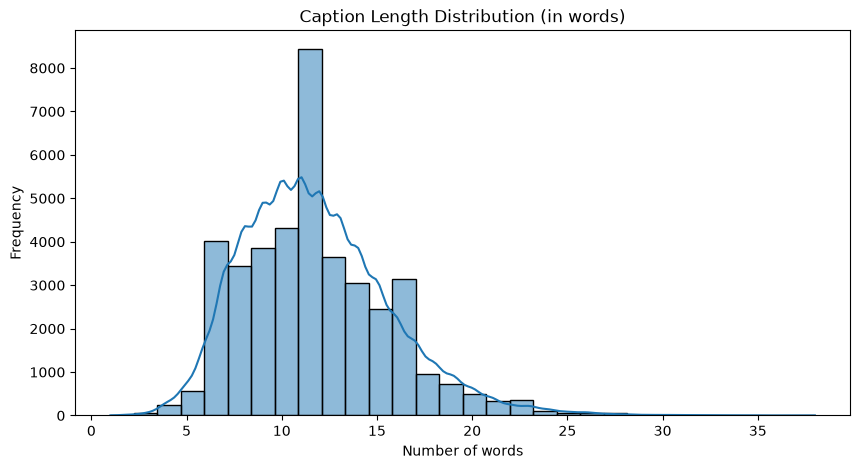

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64


In [3]:
df['caption_length'] = df['caption'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df['caption_length'], bins=30, kde=True)
plt.title("Caption Length Distribution (in words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.savefig("../notebooks/caption_length_histogram.png")
plt.show()

print(df['caption_length'].describe())

In [4]:
all_words = []
for cap in df['caption']:
    words = str(cap).lower().split()
    all_words.extend(words)

vocab = set(all_words)
word_freq = Counter(all_words)

print(f"Total words: {len(all_words)}")
print(f"Vocabulary size (unique words): {len(vocab)}")
print("\nTop 20 most common words:")
print(word_freq.most_common(20))

Total words: 476665
Vocabulary size (unique words): 8918

Top 20 most common words:
[('a', 62986), ('.', 36577), ('in', 18974), ('the', 18418), ('on', 10743), ('is', 9345), ('and', 8851), ('dog', 8136), ('with', 7765), ('man', 7265), ('of', 6713), ('two', 5638), ('white', 3940), ('black', 3832), ('boy', 3581), ('are', 3504), ('woman', 3402), ('girl', 3328), (',', 3232), ('to', 3173)]


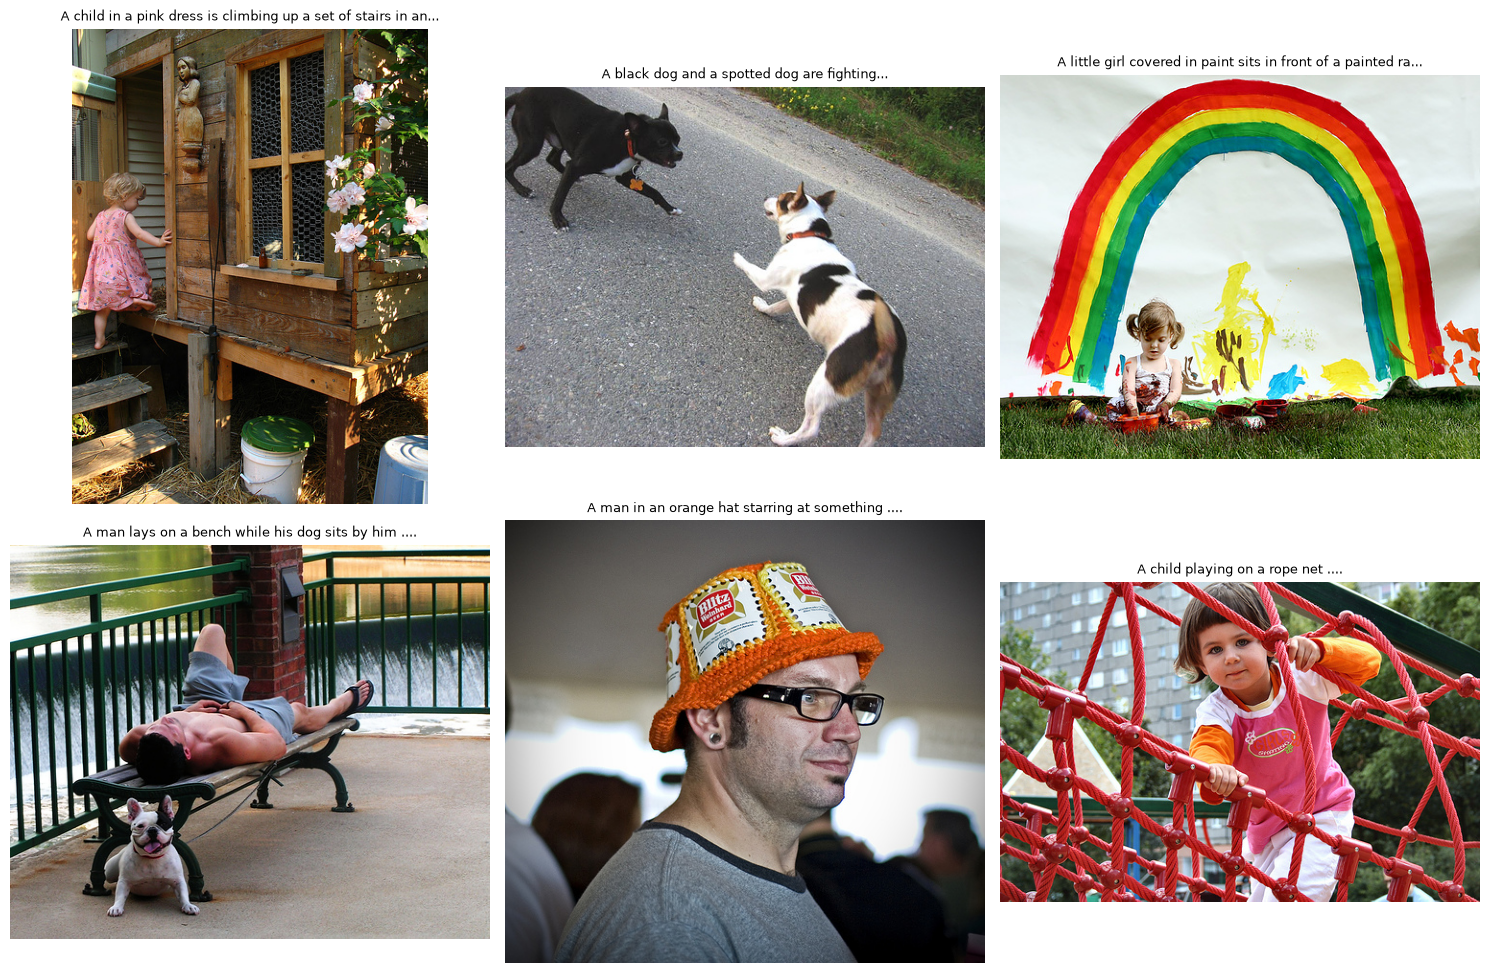

In [5]:
sample_images = df['image'].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(images_dir, img_name)
    try:
        img = Image.open(img_path)
        caption = df[df['image'] == img_name]['caption'].iloc[0]
        axes[i].imshow(img)
        axes[i].set_title(caption[:60] + "...", fontsize=9)
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Error loading {img_name}")
        axes[i].axis('off')

plt.tight_layout()
plt.savefig("../notebooks/sample_image_caption_grid.png")
plt.show()

In [6]:
duplicate_captions = df[df.duplicated(subset=['caption'], keep=False)]
print(f"Number of duplicate captions: {len(duplicate_captions)}")
duplicate_captions.head(10)

Number of duplicate captions: 448


,image,caption,caption_length
31,1009434119_febe49276a.jpg,A black and white dog is running through the g...,11
52,101654506_8eb26cfb60.jpg,A dog running through snow .,6
205,1056249424_ef2a2e041c.jpg,The children are playing in the water .,8
402,1094462889_f9966dafa6.jpg,a dog runs through the snow .,7
416,1095590286_c654f7e5a9.jpg,a dog chases another dog .,6
418,1095590286_c654f7e5a9.jpg,Two dogs are running in a field .,8
517,111537217_082a4ba060.jpg,A man is rock climbing .,6
558,1119418776_58e4b93eac.jpg,A dog running in a field .,7
816,1184967930_9e29ce380d.jpg,A dog in a field .,6
909,1222322358_225067636e.jpg,A young boy plays on a swing .,8


In [7]:
short_captions = df[df['caption_length'] <= 2]
blank_captions = df[df['caption'].isna() | (df['caption'].str.strip() == '')]

print(f"Blank captions: {len(blank_captions)}")
print(f"Very short captions (<=2 words): {len(short_captions)}")
short_captions.head(10)

Blank captions: 0
Very short captions (<=2 words): 17


,image,caption,caption_length
5585,2165461920_1a4144eb2b.jpg,dogs racing,2
9305,2428275562_4bde2bc5ea.jpg,A,1
9593,244760301_5809214866.jpg,People walking,2
11363,256085101_2c2617c5d0.jpg,Dog yawns,2
13730,2714703706_d21c5cb8df.jpg,dogs playing,2
14298,2755314937_1e974bf2b5.jpg,broken image,2
15784,2862481071_86c65d46fa.jpg,Trucks racing,2
17104,2929669711_b2d5a640f0.jpg,man surfing,2
20322,3108732084_565b423162.jpg,a snowboarder,2
20672,3125309108_1011486589.jpg,rugby match,2


In [8]:
corrupted_images = []
checked = 0

for img_name in df['image'].unique():
    img_path = os.path.join(images_dir, img_name)
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        corrupted_images.append((img_name, str(e)))
    checked += 1

print(f"Total images checked: {checked}")
print(f"Corrupted images found: {len(corrupted_images)}")
for name, err in corrupted_images[:10]:
    print(name, "-", err)

Total images checked: 8091
Corrupted images found: 0


In [9]:
summary = pd.DataFrame({
    "Metric": [
        "Total Images", "Total Captions", "Avg Captions/Image",
        "Vocabulary Size", "Avg Caption Length", "Duplicate Captions",
        "Blank/Short Captions", "Corrupted Images"
    ],
    "Value": [
        num_unique_images, num_total_captions, round(captions_per_image.mean(),2),
        len(vocab), round(df['caption_length'].mean(),2), len(duplicate_captions),
        len(short_captions), len(corrupted_images)
    ]
})
summary.to_csv("../notebooks/eda_summary.csv", index=False)
summary

,Metric,Value
0,Total Images,8091.00
1,Total Captions,40455.00
2,Avg Captions/Image,5.00
3,Vocabulary Size,8918.00
4,Avg Caption Length,11.78
5,Duplicate Captions,448.00
6,Blank/Short Captions,17.00
7,Corrupted Images,0.00
